In [1]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_score, recall_score, f1_score
from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score

In [11]:
%%capture
import os
import numpy as np
import pandas as pd

path_to_file = f"/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/synthetic_network/df_rows_0_0_0_0_0_0_0_0_0_0_0_0_08072026_004336_ncells_6000_HSC_balanced_0_0_30155b7a.csv"

gene_names = [f"gene_{i}_mRNA" for i in np.arange(1, 12)]

df = pd.read_csv(path_to_file)
df_5_gene_network = df[df['time_step'] == 1]
df_5_gene_network = df_5_gene_network[gene_names]
X = df_5_gene_network.to_numpy(dtype=np.float64)

tf_names = list(gene_names)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
    seed=101010
)
# network.to_csv(f"{path_to_plot_data}/metrics_analysis_data/grn_boost_five_gene_cascade_inference.csv")

In [12]:
def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

Best-F1 threshold: 5.2535
  F1:        0.5714
  Precision: 0.6000
  Recall:    0.5455
  # edges kept: 10


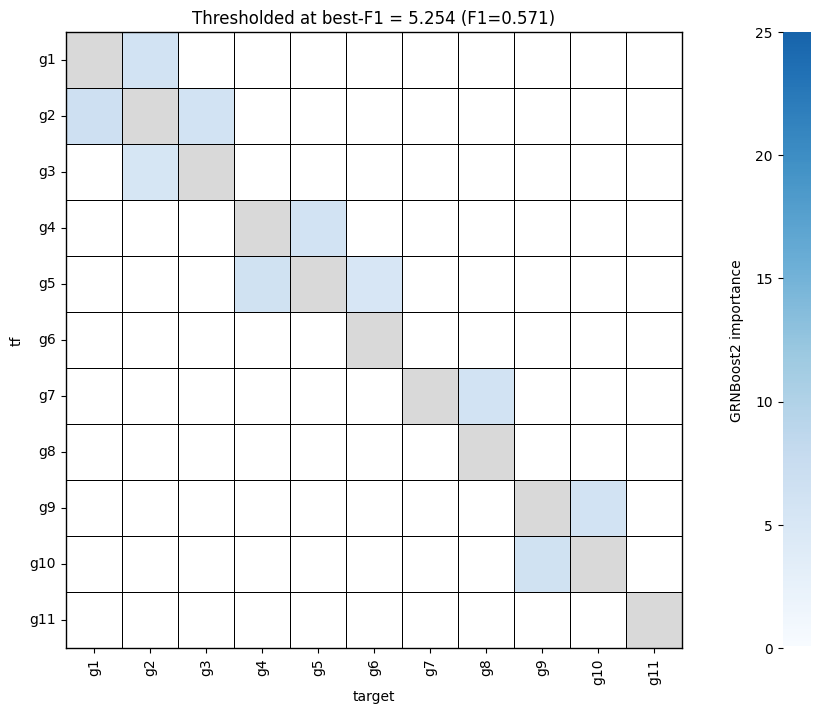

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# 1. Load ground-truth
# ============================================================
gt_path = "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/long_linear_network.txt"  # <-- update this

gt_matrix = np.loadtxt(gt_path, delimiter=",")
n_genes   = gt_matrix.shape[0]
genes     = [f"gene_{i+1}_mRNA" for i in range(n_genes)]

gt_df     = pd.DataFrame(gt_matrix, index=genes, columns=genes)
gt_binary = (gt_df.values != 0).astype(int)
np.fill_diagonal(gt_binary, 0)

mask   = ~np.eye(len(genes), dtype=bool).flatten()
y_true = gt_binary.flatten()[mask]

# ============================================================
# 2. Load the single network
# ============================================================

pred_df = (
    network
    .pivot(index="TF", columns="target", values="importance")
    .reindex(index=genes, columns=genes, fill_value=0.0)
)
np.fill_diagonal(pred_df.values, 0.0)

y_score = pred_df.values.flatten()[mask]

# ============================================================
# 3. Best-F1 threshold
# ============================================================
rows = []
for t in np.unique(y_score)[::-1]:
    y_pred = (y_score >= t).astype(int)
    if y_pred.sum() == 0:
        continue
    rows.append({
        "threshold": t,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred),
        "n_edges":   y_pred.sum(),
    })
best = pd.DataFrame(rows).loc[lambda df: df["f1"].idxmax()]

threshold = best["threshold"]
print(f"Best-F1 threshold: {threshold:.4f}")
print(f"  F1:        {best['f1']:.4f}")
print(f"  Precision: {best['precision']:.4f}")
print(f"  Recall:    {best['recall']:.4f}")
print(f"  # edges kept: {int(best['n_edges'])}")

# ============================================================
# 4. Plot thresholded matrix
# ============================================================
def to_g_label(name):
    m = re.search(r'(\d+)', str(name))
    return f"g{m.group(1)}" if m else name

def g_key(name):
    m = re.search(r'(\d+)', str(name))
    return int(m.group(1)) if m else float("inf")

heatmap_df = network.rename(columns={"TF": "tf", "target": "target", "importance": "importance"}) \
    .pivot(index="tf", columns="target", values="importance") \
    .fillna(0.0)

heatmap_df = heatmap_df.rename(columns=to_g_label, index=to_g_label)

plot_df = heatmap_df.sort_index(
    key=lambda idx: [g_key(x) for x in idx]
).sort_index(
    axis=1,
    key=lambda cols: [g_key(x) for x in cols]
)

# apply the best-F1 threshold: zero out everything below it
plot_df = plot_df.mask(plot_df < threshold, 0)

gene_labels = plot_df.index
diag_mask = np.eye(len(plot_df), dtype=bool)
vmax = 25

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(1, 2, width_ratios=[0.96, 0.04], hspace=0.08)
cbar_ax = fig.add_subplot(gs[1])
heatmap_ax = fig.add_subplot(gs[0])

cmap = make_reds_blues_colormap(vmin=0, vmax=vmax)
cmap.set_bad(color="#D9D9D9")

sns.heatmap(
    plot_df,
    ax=heatmap_ax,
    mask=diag_mask,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    square=True,
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation": "vertical"}
)

cbar_ax.yaxis.set_label_position("left")
cbar_ax.yaxis.tick_left()
cbar_ax.set_ylabel("GRNBoost2 importance", labelpad=8)

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
heatmap_ax.set_title(f"Thresholded at best-F1 = {threshold:.3f} (F1={best['f1']:.3f})")

fig.patch.set_alpha(0)
for ax in (heatmap_ax, cbar_ax):
    ax.set_facecolor("none")

for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("black")
    spine.set_clip_on(False)

plt.show()